# 09 Final Project Summary

## Objective

This notebook summarizes the full LLM stylometric fingerprinting project. It brings together the final outputs from preprocessing, feature extraction, semantic mapping, statistical testing, classification modeling, and the Streamlit dashboard.

The purpose is to produce a concise final evidence base for the written report.

## Research Question

Can stylometric features distinguish texts generated by different large language models?

## Final Analytical Logic

The project answers this question in four stages:

1. **Stylometric feature extraction**  
   I extracted measurable writing-style features from model-generated texts.

2. **Semantic mapping**  
   I tested whether model outputs cluster in sentence-embedding space.

3. **Statistical testing**  
   I tested whether stylometric features differ significantly across model families.

4. **Classification modeling**  
   I tested whether stylometric features can predict the generating model family.

In [36]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

FEATURE_PATH = PROJECT_ROOT / "data" / "features" / "final" / "stylometric_features.csv"

SILHOUETTE_PATH = PROJECT_ROOT / "outputs" / "semantic_maps" / "embedding_silhouette_scores.csv"

STAT_TEST_PATH = PROJECT_ROOT / "outputs" / "statistical_tests" / "kruskal_model_family_tests.csv"
GENRE_TEST_PATH = PROJECT_ROOT / "outputs" / "statistical_tests" / "kruskal_model_family_tests_by_genre.csv"
POSTHOC_PATH = PROJECT_ROOT / "outputs" / "statistical_tests" / "pairwise_posthoc_mannwhitney_tests.csv"

CLASSIFICATION_PATH = PROJECT_ROOT / "outputs" / "classification" / "model_performance_summary.csv"
RF_IMPORTANCE_PATH = PROJECT_ROOT / "outputs" / "classification" / "feature_importance_random_forest_all_features.csv"
FEATURE_FAMILY_PATH = PROJECT_ROOT / "outputs" / "classification" / "feature_family_importance_summary.csv"

FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
REPORT_DIR = PROJECT_ROOT / "report"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

print("Project root:", PROJECT_ROOT)
print("Report directory:", REPORT_DIR)

Project root: /Users/violaawor/Desktop/LLM-sytlometric
Report directory: /Users/violaawor/Desktop/LLM-sytlometric/report


## 1. Load final project outputs

This notebook loads only saved outputs from the modular project pipeline. It does not rerun the full generation, preprocessing, feature extraction, statistical testing, or classification scripts.

This follows the project design principle that scripts generate outputs, notebooks interpret outputs, and the final report synthesizes the findings.

In [37]:
features_df = pd.read_csv(FEATURE_PATH)
silhouette_df = pd.read_csv(SILHOUETTE_PATH)
stat_tests_df = pd.read_csv(STAT_TEST_PATH)
genre_tests_df = pd.read_csv(GENRE_TEST_PATH)
posthoc_df = pd.read_csv(POSTHOC_PATH)
classification_df = pd.read_csv(CLASSIFICATION_PATH)
rf_importance_df = pd.read_csv(RF_IMPORTANCE_PATH)
feature_family_df = pd.read_csv(FEATURE_FAMILY_PATH)

feature_columns = [col for col in features_df.columns if col.startswith("stylo_")]

print("Stylometric feature dataset:", features_df.shape)
print("Number of stylometric features:", len(feature_columns))
print("Semantic silhouette table:", silhouette_df.shape)
print("Statistical test table:", stat_tests_df.shape)
print("Genre-specific test table:", genre_tests_df.shape)
print("Post-hoc test table:", posthoc_df.shape)
print("Classification performance table:", classification_df.shape)
print("Random Forest importance table:", rf_importance_df.shape)
print("Feature-family importance table:", feature_family_df.shape)

Stylometric feature dataset: (1000, 55)
Number of stylometric features: 43
Semantic silhouette table: (3, 3)
Statistical test table: (43, 15)
Genre-specific test table: (172, 16)
Post-hoc test table: (100, 14)
Classification performance table: (8, 12)
Random Forest importance table: (43, 2)
Feature-family importance table: (6, 4)


### Interpretation

All final project outputs load successfully. The main analytical dataset contains 1,000 generated texts and 43 stylometric features.

The final project evidence comes from three major result groups:

- semantic-map results;
- statistical-test results;
- classification-modeling results.

Together, these outputs allow me to answer whether model identity is visible in semantic space, stylometric feature distributions, and supervised prediction.

In [38]:
# Dataset summary table

model_counts = features_df["model_family"].value_counts()
genre_counts = features_df["genre"].value_counts()

model_genre_balance = pd.crosstab(
    index=features_df["model_family"],
    columns=features_df["genre"],
)

texts_per_model_family = int(model_counts.min())
texts_per_genre = int(genre_counts.min())
texts_per_model_family_per_genre = int(model_genre_balance.min().min())

dataset_summary = pd.DataFrame(
    {
        "item": [
            "Total generated texts",
            "Model families",
            "Texts per model family",
            "Genres",
            "Texts per genre",
            "Texts per model family per genre",
            "Stylometric features",
            "Prompt groups",
        ],
        "value": [
            int(len(features_df)),
            int(features_df["model_family"].nunique()),
            texts_per_model_family,
            int(features_df["genre"].nunique()),
            texts_per_genre,
            texts_per_model_family_per_genre,
            int(len(feature_columns)),
            int(features_df["prompt_id"].nunique()),
        ],
    }
)

display(dataset_summary)

dataset_summary.to_csv(
    TABLE_DIR / "final_dataset_summary.csv",
    index=False,
)

,item,value
0,Total generated texts,1000
1,Model families,5
2,Texts per model family,200
3,Genres,4
4,Texts per genre,250
5,Texts per model family per genre,50
6,Stylometric features,43
7,Prompt groups,200


## 2. Dataset summary interpretation

The final dataset is balanced and suitable for model-family comparison. It contains 1,000 generated texts, with 200 texts from each of the five model families. The genre distribution is also balanced, with 250 texts per genre and 50 texts per model family per genre.

This balance is methodologically important because the project is not comparing unequal groups. Any detected model-family differences are less likely to be artifacts of one model having more outputs or one genre being overrepresented.

,label,n_classes,silhouette_score_cosine
2,theme,4,0.068524
1,genre,4,0.036065
0,model_family,5,-0.007539


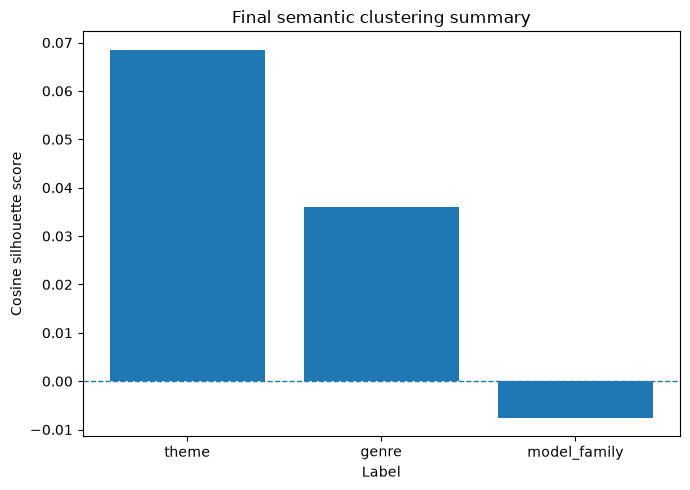

In [39]:
semantic_summary = silhouette_df.copy()
semantic_summary = semantic_summary.sort_values("silhouette_score_cosine", ascending=False)

display(semantic_summary)

plt.figure(figsize=(7, 5))
plt.bar(
    semantic_summary["label"].astype(str).tolist(),
    semantic_summary["silhouette_score_cosine"].astype(float).to_numpy(),
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Label")
plt.ylabel("Cosine silhouette score")
plt.title("Final semantic clustering summary")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "final_semantic_silhouette_summary.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Semantic mapping conclusion

The semantic-map results show weak clustering overall. The highest silhouette score belongs to `theme`, followed by `genre`, while `model_family` is slightly negative.

This means that sentence embeddings organize the texts slightly more by topic/theme than by generating model family. The model-family silhouette score being close to zero or negative indicates that the outputs from the same model are not naturally grouped together in general semantic embedding space.

This result is important because it shows that model identity is not strongly visible through broad semantic similarity. The LLMs tend to answer the same prompts with semantically similar content. Therefore, if model identity is detectable, it is more likely to appear in writing style than in general semantic content.

In [40]:
#Statistical summary
total_features = len(stat_tests_df)
significant_features = int(stat_tests_df["significant_fdr_0_05"].sum())
not_significant_features = total_features - significant_features
share_significant = significant_features / total_features

effect_counts = (
    stat_tests_df["effect_size_interpretation"]
    .value_counts()
    .rename_axis("effect_size")
    .reset_index(name="count")
)

effect_order = ["negligible", "small", "medium", "large"]
effect_counts["effect_size"] = pd.Categorical(
    effect_counts["effect_size"],
    categories=effect_order,
    ordered=True,
)
effect_counts = effect_counts.sort_values("effect_size")

statistical_summary = pd.DataFrame(
    {
        "item": [
            "Total stylometric features tested",
            "Significant after FDR correction",
            "Not significant after FDR correction",
            "Share significant",
            "Large effect features",
            "Medium effect features",
            "Small effect features",
            "Negligible effect features",
        ],
        "value": [
            total_features,
            significant_features,
            not_significant_features,
            round(share_significant, 4),
            int(effect_counts.loc[effect_counts["effect_size"] == "large", "count"].iloc[0]),
            int(effect_counts.loc[effect_counts["effect_size"] == "medium", "count"].iloc[0]),
            int(effect_counts.loc[effect_counts["effect_size"] == "small", "count"].iloc[0]),
            int(effect_counts.loc[effect_counts["effect_size"] == "negligible", "count"].iloc[0]),
        ],
    }
)

display(statistical_summary)
display(effect_counts)

statistical_summary.to_csv(TABLE_DIR / "final_statistical_summary.csv", index=False)
effect_counts.to_csv(TABLE_DIR / "final_effect_size_counts.csv", index=False)

,item,value
0,Total stylometric features tested,43.0000
1,Significant after FDR correction,41.0000
2,Not significant after FDR correction,2.0000
3,Share significant,0.9535
4,Large effect features,22.0000
5,Medium effect features,7.0000
6,Small effect features,11.0000
7,Negligible effect features,3.0000


,effect_size,count
3,negligible,3
1,small,11
2,medium,7
0,large,22


Effect-size plot

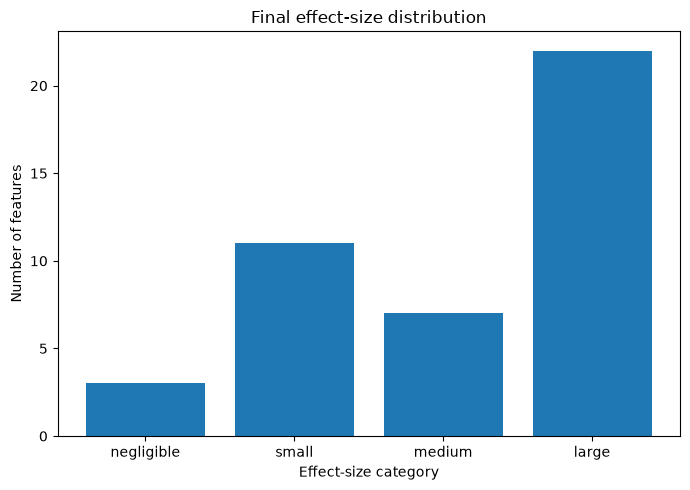

In [41]:
plt.figure(figsize=(7, 5))
plt.bar(
    effect_counts["effect_size"].astype(str).tolist(),
    effect_counts["count"].astype(int).to_numpy(),
)
plt.xlabel("Effect-size category")
plt.ylabel("Number of features")
plt.title("Final effect-size distribution")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "final_effect_size_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Statistical testing conclusion

The statistical tests provide strong evidence that the model families differ in writing style.

Out of 43 stylometric features, 41 are significant after Benjamini-Hochberg FDR correction. This means that most extracted stylometric features differ across GPT, Claude, DeepSeek, Gemini, and Mistral.

The effect-size results strengthen this conclusion. Twenty-two features have large effects, seven have medium effects, eleven have small effects, and only three have negligible effects. Therefore, the differences are not merely statistically detectable; many of them are practically meaningful.

The strongest differences occur in sentence length, punctuation, word count, function-word usage, average word length, character density, type-token ratio, and AI-style marker usage.

In [42]:
#top statistical features
top_stat_features = (
    stat_tests_df[stat_tests_df["significant_fdr_0_05"] == True]
    .sort_values(["p_value_fdr", "epsilon_squared"], ascending=[True, False])
    .head(15)
)

display(
    top_stat_features[
        [
            "feature",
            "kruskal_h",
            "p_value_fdr",
            "epsilon_squared",
            "effect_size_interpretation",
            "max_mean_model",
            "min_mean_model",
        ]
    ]
)

top_stat_features.to_csv(TABLE_DIR / "final_top_statistical_features.csv", index=False)

,feature,kruskal_h,p_value_fdr,epsilon_squared,effect_size_interpretation,max_mean_model,min_mean_model
0,stylo_sentence_length_max,312.009378,1.195103e-64,0.309557,large,DeepSeek,Claude
1,stylo_long_sentence_ratio,297.625386,6.890101e-62,0.295101,large,DeepSeek,Claude
2,stylo_comma_count,297.000150,6.890101e-62,0.294473,large,Gemini,Claude
3,stylo_word_count,293.561608,2.850581e-61,0.291017,large,DeepSeek,Mistral
4,stylo_comma_per_100_words,275.496743,1.792127e-57,0.272861,large,Gemini,Claude
5,stylo_sentence_length_std,273.477108,4.069802e-57,0.270831,large,DeepSeek,Claude
6,stylo_function_word_count,268.341940,4.462127e-56,0.265670,large,DeepSeek,Claude
7,stylo_function_word_ratio,235.777850,4.045854e-49,0.232943,large,GPT,Claude
8,stylo_avg_word_length,229.604693,7.672160e-48,0.226738,large,Claude,DeepSeek
9,stylo_sentence_length_range,207.219602,4.527682e-43,0.204241,large,DeepSeek,Claude


### Interpretation of top statistical features

The top statistical features show that model-family differences are concentrated in structural and lexical dimensions.

DeepSeek tends to have higher values for sentence-length maximum, long-sentence ratio, word count, sentence-length variability, function-word count, sentence-length range, and average sentence length. This suggests that DeepSeek produces longer and more structurally expansive prose.

Gemini has the highest comma count and comma density, indicating stronger comma-based clause structuring.

Claude has the highest average word length, character count, type-token ratio, and period density, suggesting denser lexical construction and stronger sentence segmentation.

GPT has the highest function-word ratio, suggesting a distinctive grammatical composition pattern.

These results show that the models differ not only in one feature but across multiple stylometric dimensions.

,genre,total_features,significant_features,mean_epsilon_squared,median_epsilon_squared,share_significant
0,Argumentative,43,40,0.287779,0.270063,0.930233
1,Descriptive,43,37,0.201789,0.195496,0.860465
2,Dialogue,43,38,0.228209,0.251475,0.883721
3,Narrative,43,39,0.211995,0.241725,0.906977


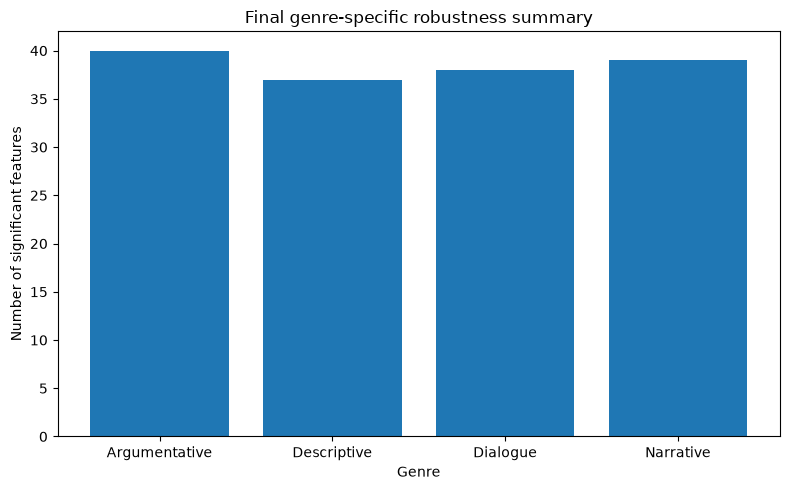

In [43]:
#Genre-specific robustness summary
genre_summary = (
    genre_tests_df.groupby("genre")
    .agg(
        total_features=("feature", "count"),
        significant_features=("significant_fdr_0_05", "sum"),
        mean_epsilon_squared=("epsilon_squared", "mean"),
        median_epsilon_squared=("epsilon_squared", "median"),
    )
    .reset_index()
)

genre_summary["share_significant"] = (
    genre_summary["significant_features"] / genre_summary["total_features"]
)

display(genre_summary)

plt.figure(figsize=(8, 5))
plt.bar(
    genre_summary["genre"].astype(str).tolist(),
    genre_summary["significant_features"].astype(int).to_numpy(),
)
plt.xlabel("Genre")
plt.ylabel("Number of significant features")
plt.title("Final genre-specific robustness summary")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "final_genre_robustness_summary.png", dpi=300, bbox_inches="tight")
plt.show()

genre_summary.to_csv(TABLE_DIR / "final_genre_robustness_summary.csv", index=False)

## 5. Genre-specific robustness conclusion

The genre-specific results show that model-family stylometric differences persist within every genre.

The number of significant features is high across all four genres:

- Argumentative: 40 out of 43 features;
- Narrative: 39 out of 43 features;
- Dialogue: 38 out of 43 features;
- Descriptive: 37 out of 43 features.

This means the model-family signal is not caused by only one genre. The stylometric differences remain visible when the analysis is repeated separately within argumentative, narrative, dialogue, and descriptive outputs.

In [44]:
posthoc_summary = pd.DataFrame(
    {
        "item": [
            "Total pairwise post-hoc tests",
            "Significant after FDR correction",
            "Share significant",
        ],
        "value": [
            len(posthoc_df),
            int(posthoc_df["significant_fdr_0_05"].sum()),
            round(float(posthoc_df["significant_fdr_0_05"].mean()), 4),
        ],
    }
)

display(posthoc_summary)

top_posthoc = posthoc_df.sort_values(
    ["p_value_fdr", "absolute_mean_difference"],
    ascending=[True, False],
).head(15)

display(
    top_posthoc[
        [
            "feature",
            "group_a",
            "group_b",
            "p_value_fdr",
            "mean_group_a",
            "mean_group_b",
            "higher_mean_group",
            "lower_mean_group",
        ]
    ]
)

posthoc_summary.to_csv(TABLE_DIR / "final_posthoc_summary.csv", index=False)
top_posthoc.to_csv(TABLE_DIR / "final_top_posthoc_comparisons.csv", index=False)

,item,value
0,Total pairwise post-hoc tests,100.00
1,Significant after FDR correction,86.00
2,Share significant,0.86


,feature,group_a,group_b,p_value_fdr,mean_group_a,mean_group_b,higher_mean_group,lower_mean_group
90,stylo_word_count,DeepSeek,GPT,1.868130e-51,218.785000,209.160000,DeepSeek,GPT
20,stylo_comma_per_100_words,Claude,Gemini,3.702520e-46,6.181178,9.707183,Gemini,Claude
10,stylo_comma_count,Claude,Gemini,1.181137e-45,12.945000,20.355000,Gemini,Claude
91,stylo_word_count,Claude,DeepSeek,8.175548e-44,209.850000,218.785000,DeepSeek,Claude
50,stylo_long_sentence_ratio,Claude,DeepSeek,2.537123e-42,0.071069,0.372563,DeepSeek,Claude
92,stylo_word_count,DeepSeek,Mistral,4.163315e-42,218.785000,203.280000,DeepSeek,Mistral
60,stylo_sentence_length_max,Claude,DeepSeek,4.163315e-42,25.550000,36.785000,DeepSeek,Claude
51,stylo_long_sentence_ratio,Claude,Gemini,1.023453e-39,0.071069,0.317542,Gemini,Claude
80,stylo_sentence_length_std,Claude,DeepSeek,5.749403e-39,5.237477,8.472700,DeepSeek,Claude
30,stylo_function_word_count,Claude,DeepSeek,2.737727e-38,56.055000,75.145000,DeepSeek,Claude


## 6. Post-hoc testing conclusion

The post-hoc tests clarify which model pairs drive the omnibus Kruskal-Wallis results.

Out of 100 pairwise Mann-Whitney U tests on the strongest features, 86 are significant after FDR correction. This confirms that the statistical differences are not vague or isolated. They are driven by concrete pairwise contrasts between model families.

Examples include DeepSeek producing longer outputs than GPT and Mistral, Gemini using more commas than Claude, and Claude having longer average word length than DeepSeek.

This makes the statistical evidence more interpretable because it identifies which models differ from each other and on which stylometric dimensions.

In [45]:
#classification summary
classification_sorted = classification_df.sort_values(
    ["macro_f1", "accuracy"],
    ascending=False,
).reset_index(drop=True)

best_model = classification_sorted.iloc[0]
random_baseline = 1 / features_df["model_family"].nunique()

classification_summary = pd.DataFrame(
    {
        "item": [
            "Random baseline",
            "Best classifier",
            "Best feature set",
            "Best accuracy",
            "Best macro F1",
            "Best weighted F1",
            "Best structure/format accuracy",
            "Best content-oriented accuracy",
        ],
        "value": [
            round(random_baseline, 3),
            best_model["model_name"],
            best_model["feature_set"],
            round(float(best_model["accuracy"]), 3),
            round(float(best_model["macro_f1"]), 3),
            round(float(best_model["weighted_f1"]), 3),
            round(
                float(
                    classification_df.loc[
                        classification_df["feature_set"] == "structure_format_features",
                        "accuracy",
                    ].max()
                ),
                3,
            ),
            round(
                float(
                    classification_df.loc[
                        classification_df["feature_set"] == "content_oriented_features",
                        "accuracy",
                    ].max()
                ),
                3,
            ),
        ],
    }
)

display(classification_summary)
display(classification_sorted)

classification_summary.to_csv(TABLE_DIR / "final_classification_summary.csv", index=False)
classification_sorted.to_csv(TABLE_DIR / "final_classification_performance_ranked.csv", index=False)

,item,value
0,Random baseline,0.2
1,Best classifier,logistic_regression
2,Best feature set,all_stylometric_features
3,Best accuracy,0.781
4,Best macro F1,0.78
5,Best weighted F1,0.78
6,Best structure/format accuracy,0.745
7,Best content-oriented accuracy,0.602


,model_name,feature_set,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,n_features,n_observations,n_prompt_groups,n_splits
0,logistic_regression,all_stylometric_features,0.781,0.781,0.780178,0.781,0.780435,0.780435,43,1000,200,5
1,random_forest,all_stylometric_features,0.779,0.779,0.777157,0.779,0.776223,0.776223,43,1000,200,5
2,random_forest,structure_format_features,0.745,0.745,0.742000,0.745,0.741636,0.741636,26,1000,200,5
3,logistic_regression,structure_format_features,0.722,0.722,0.718347,0.722,0.719621,0.719621,26,1000,200,5
4,logistic_regression,content_oriented_features,0.602,0.602,0.599001,0.602,0.598601,0.598601,17,1000,200,5
5,logistic_regression,without_structure_format_features,0.602,0.602,0.599001,0.602,0.598601,0.598601,17,1000,200,5
6,random_forest,content_oriented_features,0.571,0.571,0.565301,0.571,0.562136,0.562136,17,1000,200,5
7,random_forest,without_structure_format_features,0.569,0.569,0.564523,0.569,0.560781,0.560781,17,1000,200,5


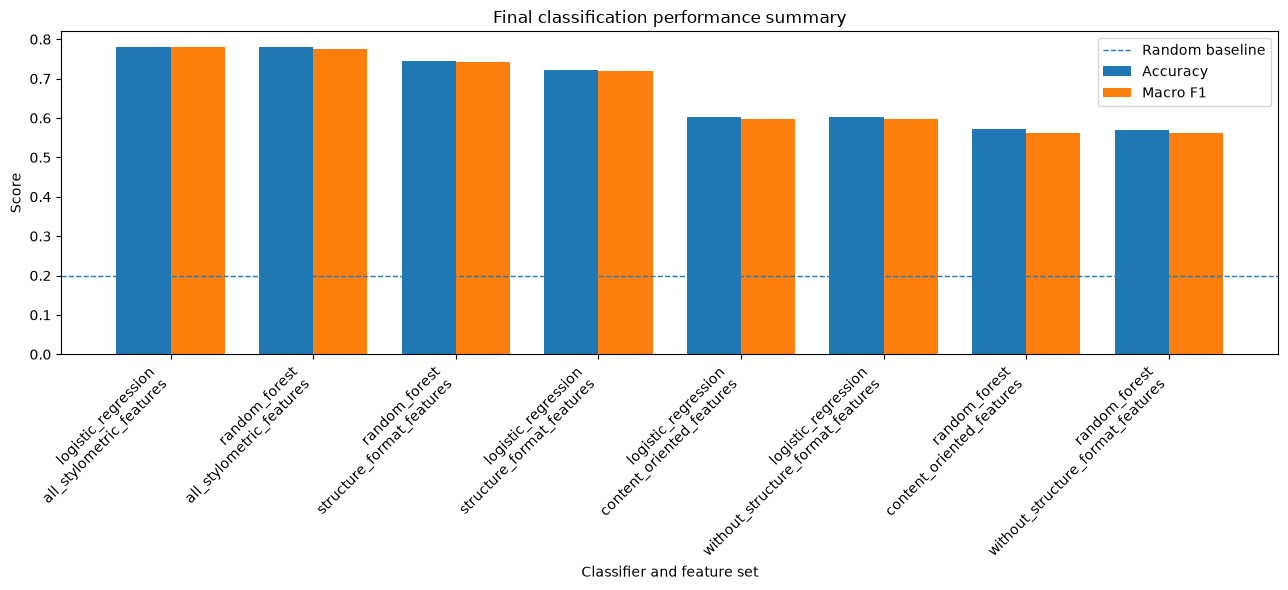

In [46]:
#classification performance plot
plot_df = classification_sorted.copy()
plot_df["model_feature_set"] = (
    plot_df["model_name"].astype(str) + "\n" + plot_df["feature_set"].astype(str)
)

x_labels = plot_df["model_feature_set"].astype(str).tolist()
accuracy_values = plot_df["accuracy"].astype(float).to_numpy()
macro_f1_values = plot_df["macro_f1"].astype(float).to_numpy()

x_positions = np.arange(len(x_labels))
bar_width = 0.38

plt.figure(figsize=(13, 6))
plt.bar(x_positions - bar_width / 2, accuracy_values, width=bar_width, label="Accuracy")
plt.bar(x_positions + bar_width / 2, macro_f1_values, width=bar_width, label="Macro F1")
plt.axhline(random_baseline, linestyle="--", linewidth=1, label="Random baseline")
plt.xticks(x_positions, x_labels, rotation=45, ha="right")
plt.ylabel("Score")
plt.xlabel("Classifier and feature set")
plt.title("Final classification performance summary")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "final_classification_performance_summary.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Classification conclusion

The classification results provide the strongest predictive evidence for model-family stylometric fingerprinting.

The best model is Logistic Regression using all 43 stylometric features, with 78.1% accuracy and 0.780 macro F1. Random Forest with all stylometric features performs almost identically, with 77.9% accuracy and 0.776 macro F1.

Because the dataset has five balanced model families, the random baseline is 20%. Therefore, the best classifier performs almost four times better than chance.

The feature-set comparison is also important. Structure/format features alone achieve up to 74.5% accuracy, while content-oriented features reach approximately 60.2% accuracy. This shows that model identity is especially visible in formal writing patterns such as sentence structure, punctuation, word count, and character density.

The classification design uses prompt-aware GroupKFold cross-validation, meaning the same prompt IDs are not shared across training and testing folds. This reduces prompt leakage and makes the result a stronger test of model-family writing style.

,feature,importance
0,stylo_word_count,0.075832
1,stylo_avg_word_length,0.041416
2,stylo_character_count,0.041354
3,stylo_sentence_length_std,0.039381
4,stylo_comma_per_100_words,0.037727
5,stylo_punctuation_per_100_words,0.037499
6,stylo_function_word_count,0.035403
7,stylo_type_token_ratio,0.034445
8,stylo_long_sentence_ratio,0.034249
9,stylo_comma_count,0.032765


,feature_family,total_importance,mean_importance,n_features
0,length_structure,0.409051,0.029218,14
1,punctuation,0.260756,0.021730,12
2,lexical_diversity,0.142951,0.020422,7
3,markers_function_words,0.118956,0.016994,7
4,readability,0.053283,0.026641,2
5,casing,0.015004,0.015004,1


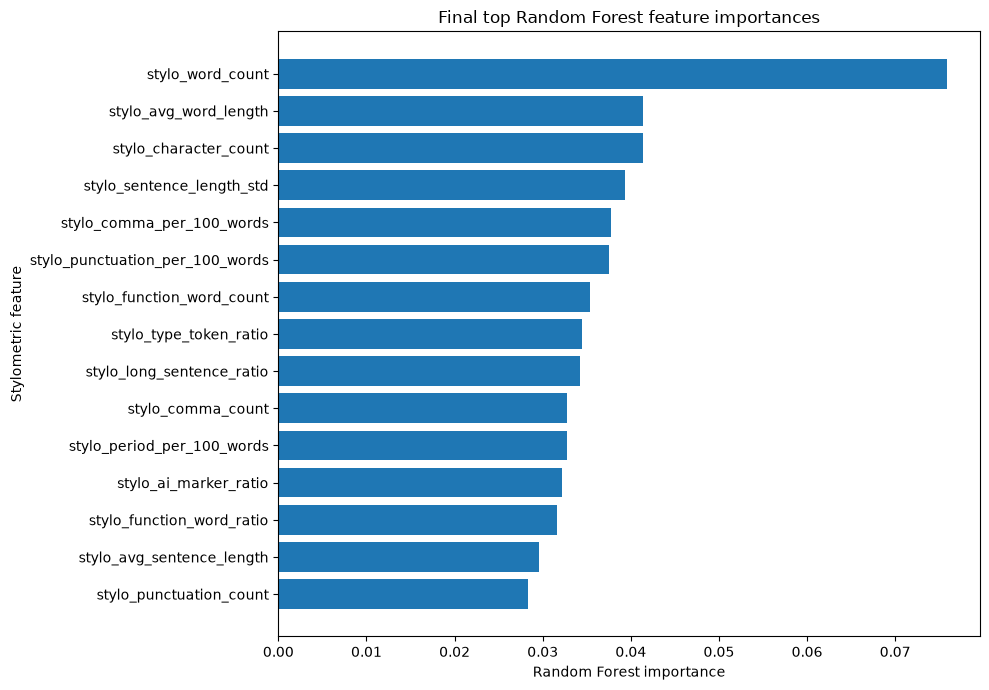

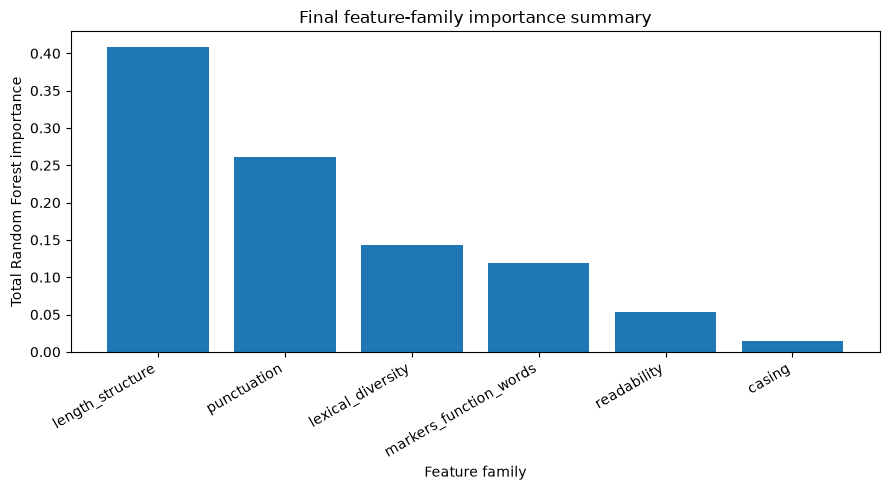

In [47]:
#feature importance summary
top_importance = rf_importance_df.head(15).copy()

display(top_importance)
display(feature_family_df)

plt.figure(figsize=(10, 7))
plt.barh(
    top_importance["feature"].astype(str).tolist()[::-1],
    top_importance["importance"].astype(float).to_numpy()[::-1],
)
plt.xlabel("Random Forest importance")
plt.ylabel("Stylometric feature")
plt.title("Final top Random Forest feature importances")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "final_top_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(
    feature_family_df["feature_family"].astype(str).tolist(),
    feature_family_df["total_importance"].astype(float).to_numpy(),
)
plt.xlabel("Feature family")
plt.ylabel("Total Random Forest importance")
plt.title("Final feature-family importance summary")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "final_feature_family_importance.png", dpi=300, bbox_inches="tight")
plt.show()

top_importance.to_csv(TABLE_DIR / "final_top_feature_importance.csv", index=False)
feature_family_df.to_csv(TABLE_DIR / "final_feature_family_importance.csv", index=False)

## 8. Feature-importance conclusion

The feature-importance results show which stylometric features are most useful for model-family prediction in the Random Forest model.

The most important features are concentrated in structural, punctuation, lexical, and marker-based dimensions. This matches the earlier statistical results, where sentence length, comma usage, word count, function-word usage, average word length, and lexical diversity were among the strongest model-family differences.

The feature-family summary reinforces the broader interpretation: model identity is not represented by one isolated feature. Instead, it is distributed across several dimensions of writing style.

final evidence table

In [48]:
final_evidence = pd.DataFrame(
    {
        "analysis_stage": [
            "Dataset design",
            "Semantic mapping",
            "Statistical testing",
            "Genre robustness",
            "Post-hoc testing",
            "Classification modeling",
            "Streamlit dashboard",
        ],
        "main_result": [
            "Balanced corpus of 1,000 texts across five model families and four genres",
            "Model-family silhouette score is close to zero/negative; theme has the strongest but weak semantic signal",
            "41 out of 43 stylometric features significant after FDR correction",
            "37–40 significant features within each genre",
            "86 out of 100 pairwise post-hoc tests significant after FDR correction",
            "Best classifier reaches 78.1% accuracy and 0.780 macro F1",
            "Interactive dashboard presents dataset, semantic maps, statistical tests, classification, and conclusions",
        ],
        "interpretation": [
            "The controlled design supports fair model-family comparison",
            "Semantic content alone does not strongly reveal model identity",
            "Stylometric features show systematic model-family differences",
            "The stylometric signal persists across prompt genres",
            "Omnibus differences are driven by concrete model-to-model contrasts",
            "Stylometric features can predict generating model family far above chance",
            "The project outputs are reproducible and interpretable for presentation",
        ],
    }
)

display(final_evidence)
final_evidence.to_csv(TABLE_DIR / "final_project_evidence_table.csv", index=False)

,analysis_stage,main_result,interpretation
0,Dataset design,"Balanced corpus of 1,000 texts across five mod...",The controlled design supports fair model-fami...
1,Semantic mapping,Model-family silhouette score is close to zero...,Semantic content alone does not strongly revea...
2,Statistical testing,41 out of 43 stylometric features significant ...,Stylometric features show systematic model-fam...
3,Genre robustness,37–40 significant features within each genre,The stylometric signal persists across prompt ...
4,Post-hoc testing,86 out of 100 pairwise post-hoc tests signific...,Omnibus differences are driven by concrete mod...
5,Classification modeling,Best classifier reaches 78.1% accuracy and 0.7...,Stylometric features can predict generating mo...
6,Streamlit dashboard,"Interactive dashboard presents dataset, semant...",The project outputs are reproducible and inter...


## 9. Final answer to the research question

The final answer to the research question is yes.

Stylometric features can distinguish texts generated by different LLM families. The evidence is consistent across statistical testing and supervised classification.

The semantic maps show that model-family identity is not strongly visible in general sentence-embedding space. This means the models produce semantically similar answers when they respond to the same prompts.

However, stylometric analysis reveals strong model-family differences. Most stylometric features differ significantly across model families, and those differences are large enough to support model-family prediction with approximately 78% accuracy.

Therefore, the project concludes that LLMs do have measurable writing-style fingerprints. These fingerprints are especially visible in sentence structure, punctuation, word count, character density, function-word usage, lexical diversity, and readability-related patterns.

In [49]:
#save final markdown summary
final_markdown_summary = """
# Final Project Summary

## Research Question

Can stylometric features distinguish texts generated by different LLMs?

## Final Answer

Yes. The project finds strong evidence that stylometric features can distinguish texts generated by different LLM families.

## Dataset

The final dataset contains 1,000 generated texts from five model families: GPT, Claude, DeepSeek, Gemini, and Mistral. Each model contributes 200 texts. The corpus is balanced across four genres, with 250 texts per genre and 50 texts per model family per genre.

## Semantic Mapping

Sentence-embedding maps show weak model-family clustering. The model-family silhouette score is close to zero or negative, while theme has the strongest but still weak semantic signal. This suggests that semantic embeddings capture prompt theme more than generating model identity.

## Statistical Testing

Out of 43 stylometric features, 41 are significant after Benjamini-Hochberg FDR correction. Twenty-two features have large effects and seven have medium effects. These results show that model families differ systematically in writing style.

## Genre Robustness

The model-family signal persists within genres. Argumentative outputs have 40 significant features, Narrative has 39, Dialogue has 38, and Descriptive has 37.

## Post-hoc Testing

Out of 100 pairwise Mann-Whitney U post-hoc tests on the strongest features, 86 are significant after FDR correction. This confirms that the model-family differences are driven by concrete model-to-model stylistic contrasts.

## Classification

The best classifier is Logistic Regression using all 43 stylometric features. It achieves 78.1% accuracy and 0.780 macro F1 under prompt-aware GroupKFold cross-validation. Random Forest performs almost identically. Structure/format features alone achieve up to 74.5% accuracy.

## Conclusion

The LLMs generate semantically similar responses to the same prompts, but they do not write in identical styles. Their outputs contain measurable model-family fingerprints that can be detected through stylometric features.
""".strip()

summary_path = REPORT_DIR / "final_project_summary.md"

with open(summary_path, "w", encoding="utf-8") as file:
    file.write(final_markdown_summary)

print("Saved final project summary to:", summary_path)

Saved final project summary to: /Users/violaawor/Desktop/LLM-sytlometric/report/final_project_summary.md


## 10. Notebook conclusion

This notebook consolidates the final evidence from the full project pipeline.

The final result is clear: stylometric features distinguish model families more effectively than semantic embeddings. Semantic maps show weak model-family clustering, but statistical tests and classification models reveal strong model-specific writing-style signals.

This final summary notebook provides the evidence base for the written report and final project presentation.